In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------


desc = [
    "FFFS",
    "FHFF",
    "FFFF",
    "HGFH"
]

env = gym.make(
    "FrozenLake-v1",
    desc=desc,
    is_slippery=False
)


In [ ]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor

epsilon = 1.0        # Initial exploration rate
epsilon_min = 0.05
epsilon_decay = 0.9995

In [ ]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------



# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    """
    Selects an action using epsilon-greedy strategy.
    """
    # Write your code here
    if np.random.random() < epsilon:
        action = env.action_space.sample()
    else:
        # Exploitation: choose the best action
        action = np.argmax(Q[state])

    return action

In [ ]:
# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

# Initialize Q-table with zeros
Q = np.zeros((env.observation_space.n, env.action_space.n))

episode_rewards = []

for episode in range(num_episodes):

    # Reset the environment
    state, info = env.reset()

    # Choose initial action using epsilon-greedy policy
    action = epsilon_greedy_action(state, epsilon)

    total_reward = 0

    for step in range(max_steps_per_episode):

        # Take the selected action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Check whether the episode is finished
        done = terminated or truncated

        # Choose next action using epsilon-greedy policy
        next_action = epsilon_greedy_action(next_state, epsilon)

        # SARSA update rule
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * Q[next_state, next_action] - Q[state, action]
        )

        # Move to the next state and action
        state = next_state
        action = next_action

        # Add reward
        total_reward += reward

        # Stop if the episode is finished
        if done:
            break

    # Store the total reward for this episode
    episode_rewards.append(total_reward)

    # Reduce epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)


# -------------------------------------------------
# Extract State Values and Policy
# -------------------------------------------------

state_values = np.max(Q, axis=1)

policy = np.argmax(Q, axis=1)

In [ ]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [ ]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.025 0.359 0.06  0.009]
 [0.132 0.    0.865 0.214]
 [0.774 0.802 0.903 0.817]
 [0.856 0.955 0.852 0.856]
 [0.148 0.771 0.    0.016]
 [0.    0.    0.    0.   ]
 [0.    0.919 0.886 0.88 ]
 [0.842 0.968 0.903 0.884]
 [0.607 0.    0.988 0.37 ]
 [0.956 1.    0.962 0.   ]
 [0.856 0.988 0.853 0.825]
 [0.979 0.    0.879 0.891]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [1.    0.99  0.    0.965]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.359 0.865 0.903 0.955]
 [0.771 0.    0.919 0.968]
 [0.988 1.    0.988 0.979]
 [0.    0.    1.    0.   ]]

Learned Policy:
[['D' 'R' 'R' 'D']
 ['D' 'L' 'D' 'D']
 ['R' 'D' 'D' 'L']
 ['L' 'L' 'L' 'L']]

Average reward over last 1000 episodes: 0.97


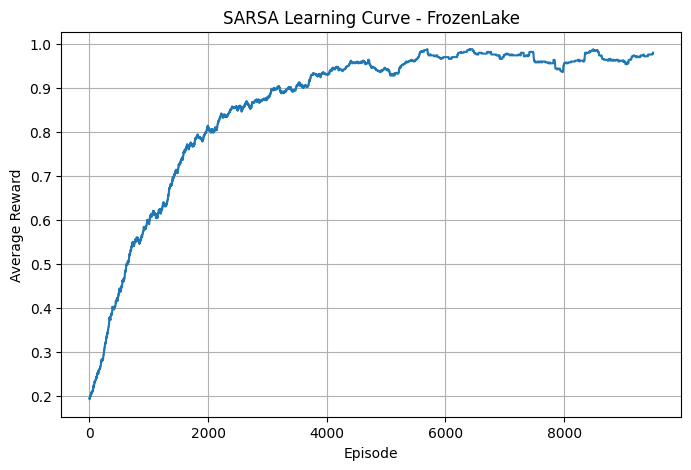

In [ ]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("SARSA Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()